In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
import umap.umap_ as umap

In [3]:
print("Loading Brazilian dataset...")

dataset = load_dataset(
    "joelniklaus/brazilian_court_decisions",
    split="train[:2000]"  
)

df = pd.DataFrame(dataset)

print("Dataset loaded!")
print("Shape:", df.shape)
print("Columns:", df.columns)

Loading Brazilian dataset...
Dataset loaded!
Shape: (2000, 10)
Columns: Index(['process_number', 'orgao_julgador', 'publish_date', 'judge_relator',
       'ementa_text', 'decision_description', 'judgment_text',
       'judgment_label', 'unanimity_text', 'unanimity_label'],
      dtype='object')


In [5]:
TEXT_COLUMN = "decision_description"

df = df[[TEXT_COLUMN]].dropna().reset_index(drop=True)

print("Using column:", TEXT_COLUMN)
print("Documents:", len(df))

Using column: decision_description
Documents: 2000


In [7]:
def clean_brazilian_text(text):
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text)         # Remove HTML
    text = re.sub(r'\s+', ' ', text)          # Remove extra spaces
    text = re.sub(r'[^a-zA-ZÀ-ÿ0-9\s]', ' ', text)
    return text.strip()

df["clean_text"] = df[TEXT_COLUMN].apply(clean_brazilian_text)

In [9]:
model = SentenceTransformer('all-MiniLM-L6-v2')

C:\Users\natra\anaconda3\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [11]:
texts = df["clean_text"].tolist()

embeddings = model.encode(
    texts,
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embedding shape:", embeddings.shape)

Batches:   0%|          | 0/125 [00:00<?, ?it/s]

Embedding shape: (2000, 384)


In [13]:
similarity_matrix = cosine_similarity(embeddings)

In [15]:
num_clusters = 8

kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df["cluster"] = kmeans.fit_predict(embeddings)

df.head()

,decision_description,clean_text,cluster
0,DIREITO PENAL E PROCESSUAL PENAL. REVISÃO CRIM...,DIREITO PENAL E PROCESSUAL PENAL REVISÃO CRIM...,5
1,APELAÇÃO CÍVEL. MANDADO DE SEGURANÇA. SERVIDOR...,APELAÇÃO CÍVEL MANDADO DE SEGURANÇA SERVIDOR...,6
2,PROCESSUAL CIVIL. EMBARGOS DE DECLARAÇÃO EM AG...,PROCESSUAL CIVIL EMBARGOS DE DECLARAÇÃO EM AG...,4
3,AGRAVO DE INSTRUMENTO. AUXÍLIO DOENÇA. SUSPENS...,AGRAVO DE INSTRUMENTO AUXÍLIO DOENÇA SUSPENS...,6
4,DIREITO DO CONSUMIDOR. APELAÇÃO INTERPOSTA EM ...,DIREITO DO CONSUMIDOR APELAÇÃO INTERPOSTA EM ...,2


Running UMAP...


C:\Users\natra\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


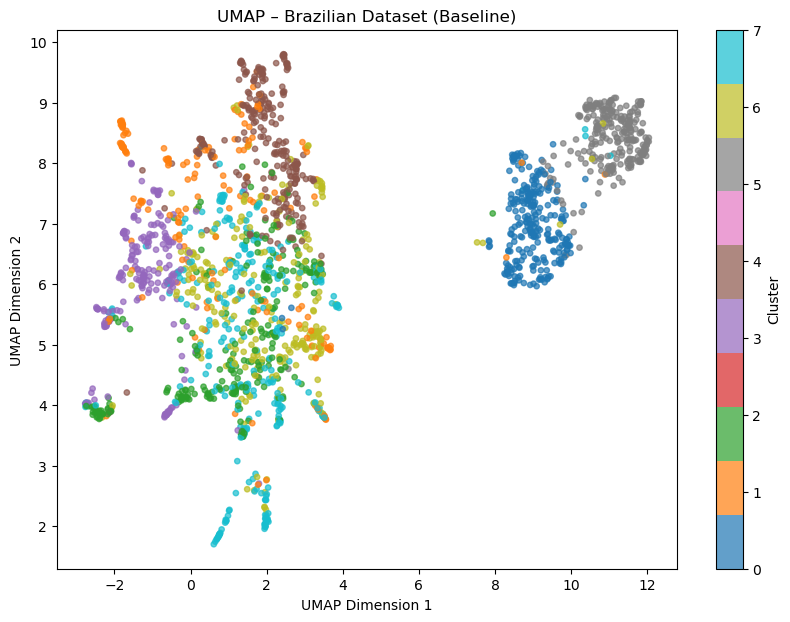

In [17]:
print("Running UMAP...")

umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    metric="cosine",
    random_state=42
)

umap_embeddings = umap_model.fit_transform(embeddings)

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    umap_embeddings[:,0],
    umap_embeddings[:,1],
    c=df["cluster"],
    cmap="tab10",
    s=15,
    alpha=0.7
)

plt.title("UMAP – Brazilian Dataset (Baseline)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

In [19]:
def find_similar(index, top_k=5):
    scores = similarity_matrix[index]
    top_idx = np.argsort(scores)[::-1][1:top_k+1]

    print("="*80)
    print("QUERY DOCUMENT")
    print("="*80)
    print(df.iloc[index]["clean_text"][:300])

    print("\n\nSIMILAR DOCUMENTS")
    print("="*80)

    for i in top_idx:
        print("\n----------------------------------")
        print("Similarity:", round(float(scores[i]), 3))
        print(df.iloc[i]["clean_text"][:200])

In [21]:
find_similar(0)

QUERY DOCUMENT
DIREITO PENAL E PROCESSUAL PENAL  REVISÃO CRIMINAL  ARTIGO 621 DO CÓDIGO DE PROCESSO PENAL  REQUERENTE CONDENADO EM JÚRI POPULAR PELA PRÁTICA DOS CRIMES DE HOMICÍDIO DUPLAMENTE QUALIFICADO E HOMICÍDIO QUALIFICADO TENTADO  PLEITO DE REFAZIMENTO DA DOSIMETRIA DA PENA IMPOSTA AO REQUERENTE  ADMISSIBILI


SIMILAR DOCUMENTS

----------------------------------
Similarity: 0.918
DIREITO PENAL E PROCESSUAL PENAL  REVISÃO CRIMINAL  ARTIGO 621 DO CÓDIGO DE PROCESSO PENAL  REQUERENTE CONDENADO EM JÚRI POPULAR PELA PRÁTICA DOS CRIMES PREVISTOS NO ARTIGO 121  PARAGRAFO 2  I  III E 

----------------------------------
Similarity: 0.89
PENAL E PROCESSUAL PENAL  APELAÇÃO CRIMINAL  HOMICÍDIO QUALIFICADO TENTADO  DOSIMETRIA  ALEGAÇÃO DE EQUÍVOCO NA FIXAÇÃO DA PENA BASE  NÃO VERIFICADO  FUNDAMENTAÇÃO CONCRETA E IDÔNEA  FRAÇÃO DA CAUSA D

----------------------------------
Similarity: 0.886
PENAL  PROCESSO PENAL  ESTELIONATO  ARTIGO 171  PARAGRAFO2  CAPUT  DO CODIGO PENAL  INSURGÊNCIA VOLTA

In [23]:
def search_new_case_brazil(new_text, top_k=5):

    # Step 1: Clean the new case
    cleaned = clean_brazilian_text(new_text)

    # Step 2: Generate embedding
    new_embedding = model.encode(
        [cleaned],
        convert_to_numpy=True
    )

    # Step 3: Compute cosine similarity
    scores = cosine_similarity(new_embedding, embeddings)[0]

    # Step 4: Get top-k indices
    top_idx = np.argsort(scores)[::-1][:top_k]

    print("="*80)
    print("NEW CASE INPUT")
    print("="*80)
    print(cleaned[:400])

    print("\n\nMOST SIMILAR BRAZILIAN CASES (Baseline)")
    print("="*80)

    for rank, i in enumerate(top_idx, start=1):
        print(f"\n🔹 Rank {rank}")
        print("----------------------------------")
        print("Similarity:", round(float(scores[i]), 3))
        print("Preview:", df.iloc[i]["clean_text"][:300])

In [29]:
new_case_text = """
Trata-se de recurso relacionado a indenização por danos morais decorrentes
de acidente de trânsito. A parte autora alega negligência do réu e requer
compensação financeira pelos prejuízos sofridos.
"""

search_new_case_brazil(new_case_text)

NEW CASE INPUT
Trata se de recurso relacionado a indenização por danos morais decorrentes de acidente de trânsito  A parte autora alega negligência do réu e requer compensação financeira pelos prejuízos sofridos


MOST SIMILAR BRAZILIAN CASES (Baseline)

🔹 Rank 1
----------------------------------
Similarity: 0.738
Preview: APELAÇÃO CÍVEL  AÇÃO DE COBRANÇA DE SEGURO DPVAT  ACIDENTE DE TRÂNSITO QUE CULMINOU EM MORTE  NEXO CAUSAL COMPROVADO NOS AUTOS  RENÚNCIA DOS DESCENDENTES EM FAVOR DA AUTORA APELADA  DIREITO PATRIMONIAL DISPONÍVEL  RECEBIMENTO DA INTEGRALIDADE DA INDENIZAÇÃO PELA DEMANDANTE APELADA  JUROS E CORREÇÃO 

🔹 Rank 2
----------------------------------
Similarity: 0.723
Preview: RECURSO DE APELAÇÃO  ATO ADMINISTRATIVO  IRRESIGNAÇÃO DO DEPARTAMENTO ESTADUAL DE TRÂNSITO  ARGUMENTAÇÃO DE ILEGITIMIDADE PASSIVA  AFASTADA  ÓRGÃO RESPONSÁVEL PELA ARRECADAÇÃO DAS MULTAS E EMISSÃO DO DOCUMENTO DO VEÍCULO  ALEGAÇÃO DE INADEQUAÇÃO DA VIA ELEITA  NÃO ACOLHIDA  MULTA APLICADA SEM OBSERV


In [ ]:
BASELINE OUTPUT (English Translation)
NEW CASE INPUT

This is an appeal related to compensation for moral damages arising from a traffic accident.
The plaintiff alleges negligence by the defendant and seeks financial compensation for the losses suffered.

MOST SIMILAR BRAZILIAN CASES (Baseline)
🔹 Rank 1

Similarity: 0.738

Preview:
CIVIL APPEAL – ACTION FOR COLLECTION OF DPVAT INSURANCE – TRAFFIC ACCIDENT RESULTING IN DEATH – CAUSAL LINK PROVEN IN THE RECORDS 
– WAIVER BY THE DESCENDANTS IN FAVOR OF THE APPELLEE – AVAILABLE PROPERTY RIGHT – RECEIPT OF THE FULL INDEMNITY BY THE CLAIMANT APPELLEE
– INTEREST AND MONETARY CORRECTION.

🔹 Rank 2

Similarity: 0.723

Preview:
APPEAL – ADMINISTRATIVE ACT – APPEAL BY THE STATE TRAFFIC DEPARTMENT – ARGUMENT OF LACK OF PASSIVE LEGITIMACY 
– REJECTED – BODY RESPONSIBLE FOR COLLECTION OF FINES AND ISSUANCE OF VEHICLE DOCUMENT – ALLEGATION OF IMPROPER PROCEDURAL ROUTE – NOT ACCEPTED – FINE IMPOSED WITHOUT OBSERVANCE.

🔹 Rank 3

Similarity: 0.692

Preview:
ADMINISTRATIVE LAW – APPEAL – IRREGULAR PASSENGER TRANSPORT – SEIZURE OF VEHICLE – IMPOSITION OF A MORE SEVERE PENALTY THAN THAT PROVIDED
IN THE BRAZILIAN TRAFFIC CODE – DIRECT ACTION OF UNCONSTITUTIONALITY – MUNICIPAL LAW NUMBER 6466/2015 WHICH PROVIDES FOR THE PROHIBITION OF THE PRACTICE.

🔹 Rank 4

Similarity: 0.689

Preview:
MANDATORY REVIEW – WRIT OF MANDAMUS – MUNICIPAL PUBLIC SERVANT – TRAFFIC INSPECTION AGENT – MUNICIPALITY OF MACEIÓ 
– CAREER PROGRESSION BY QUALIFICATION – COMPLETION OF HIGHER EDUCATION EXCEEDING THE LEVEL REQUIRED FOR THE POSITION – ARTICLE 20, VII, ITEMS 1 AND 4 OF THE LAW.

🔹 Rank 5

Similarity: 0.683

Preview:
CIVIL APPEAL – CIVIL LIABILITY IN TRAFFIC ACCIDENT – COMPENSATION ACTION – SUBJECTIVE CIVIL LIABILITY – INVASION OF LANE OCCUPIED BY THE APPELLEE – MATERIAL DAMAGES – DUTY TO INDEMNIFY – MORAL DAMAGE VERIFIED IN THE CASE – COMPENSATION AMOUNT FIXED AT R$ 15,000.00 (FIFTEEN THOUSAND REAIS) – REDUCTION.

In [ ]:
new_case_text = """
Trata-se de recurso relacionado a indenização por danos morais decorrentes
de acidente de trânsito. A parte autora alega negligência do réu e requer
compensação financeira pelos prejuízos sofridos.
"""

In [ ]:
new_case_text = """
Trata-se de recurso em ação revisional de contrato bancário.
A parte autora alega cobrança de juros abusivos e requer a
revisão das cláusulas contratuais com restituição dos valores pagos.
"""